In [1]:
import warnings

warnings.simplefilter("ignore", FutureWarning)

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig4"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(8,8),
                                   vector_friendly=True
                             )


# Load

In [3]:
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna')
import gc
gc.collect()
adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

 

In [4]:
# sc.pp.subsample(adata, 0.05)
# adata.shape


In [5]:
# adata.write('/nfs/team298/ls34/adult_skin/final_adatas/adata_skin_scrna_subsampled.h5ad')

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)


In [7]:
# sc.pl.dotplot(
#     adata,
#      [ 'CD38', 
                   
#                     ],
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     swap_axes=True,
#        # dot_max=0.3,
#    # save='plotTNFRSF17_TNFSF13_scrna.pdf',
#       #  title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [8]:
# sc.pl.dotplot(
#     adata,
#      [ 'TNFSF13', 
#                     'TNFRSF17'
#                     ],
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     swap_axes=True,
#        # dot_max=0.3,
#     save='plotTNFRSF17_TNFSF13_scrna.pdf',
#         title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


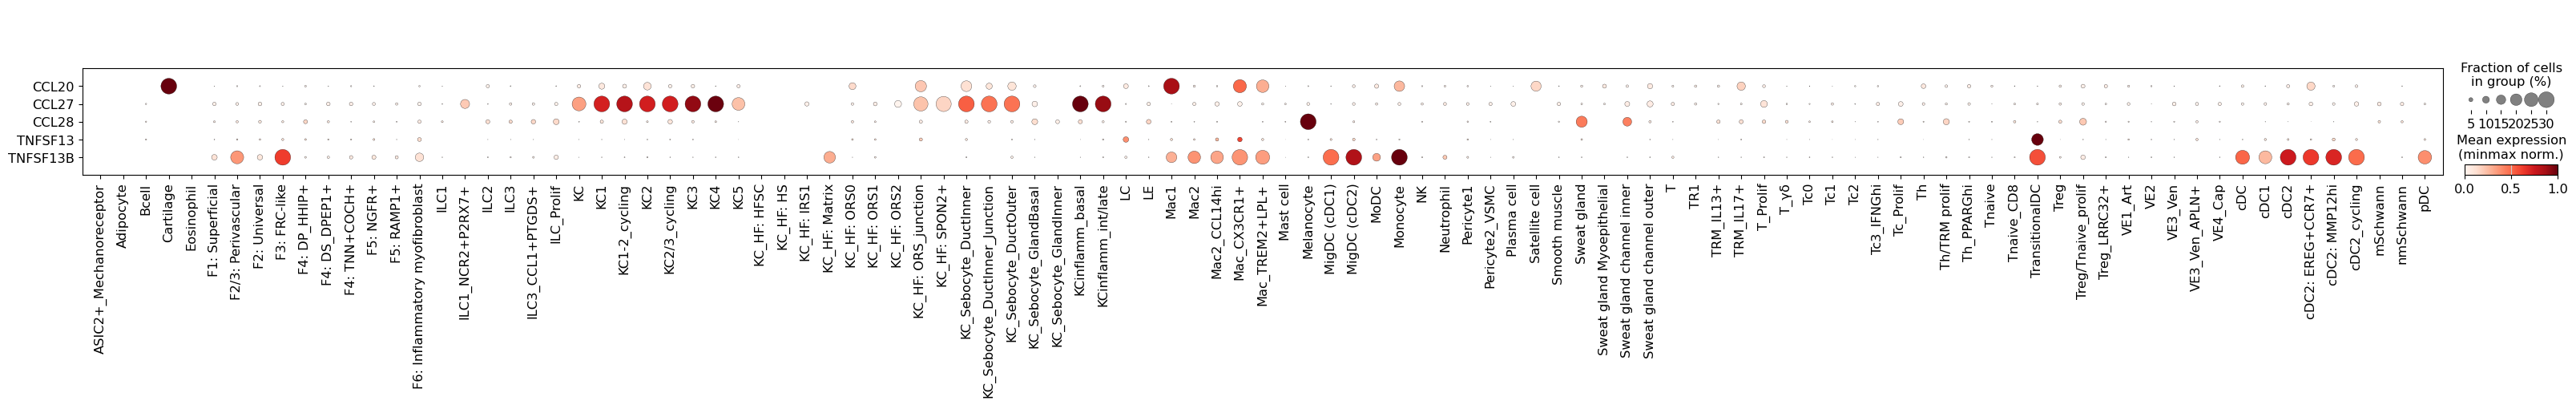

In [9]:
sc.pl.dotplot(
    adata[adata.obs["Patient_status"]=="AD"],
     ["CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B',],
    groupby="lvl5_annotation",
  #  vmax=0.8,
  #  categories_order=ORDER,
        dot_max=0.3,
    standard_scale="var",
    colorbar_title="Mean expression\n(minmax norm.)",
    swap_axes=True,
    save="plasmacell_signalling_allcells.pdf"

   # save='4h_plasma_Cell_dotplot1.pdf'
)

# sc.pl.dotplot(
#     adata,
#        ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
#     groupby="lvl5_annotation",
#     #vmax=0.8,
#     dot_max=0.3,
#         standard_scale="var",

#     categories_order=ORDER,
#     colorbar_title="Mean expression\n(minmax norm.)",
#   #  save='4h_plasma_Cell_dotplot2_minmax.pdf'
# )

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [10]:
order = list(sorted(adata.obs["lvl5_annotation"].unique()))

priority = ["Plasma cell", "Bcell"]

order = priority + [x for x in order if x not in priority]

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


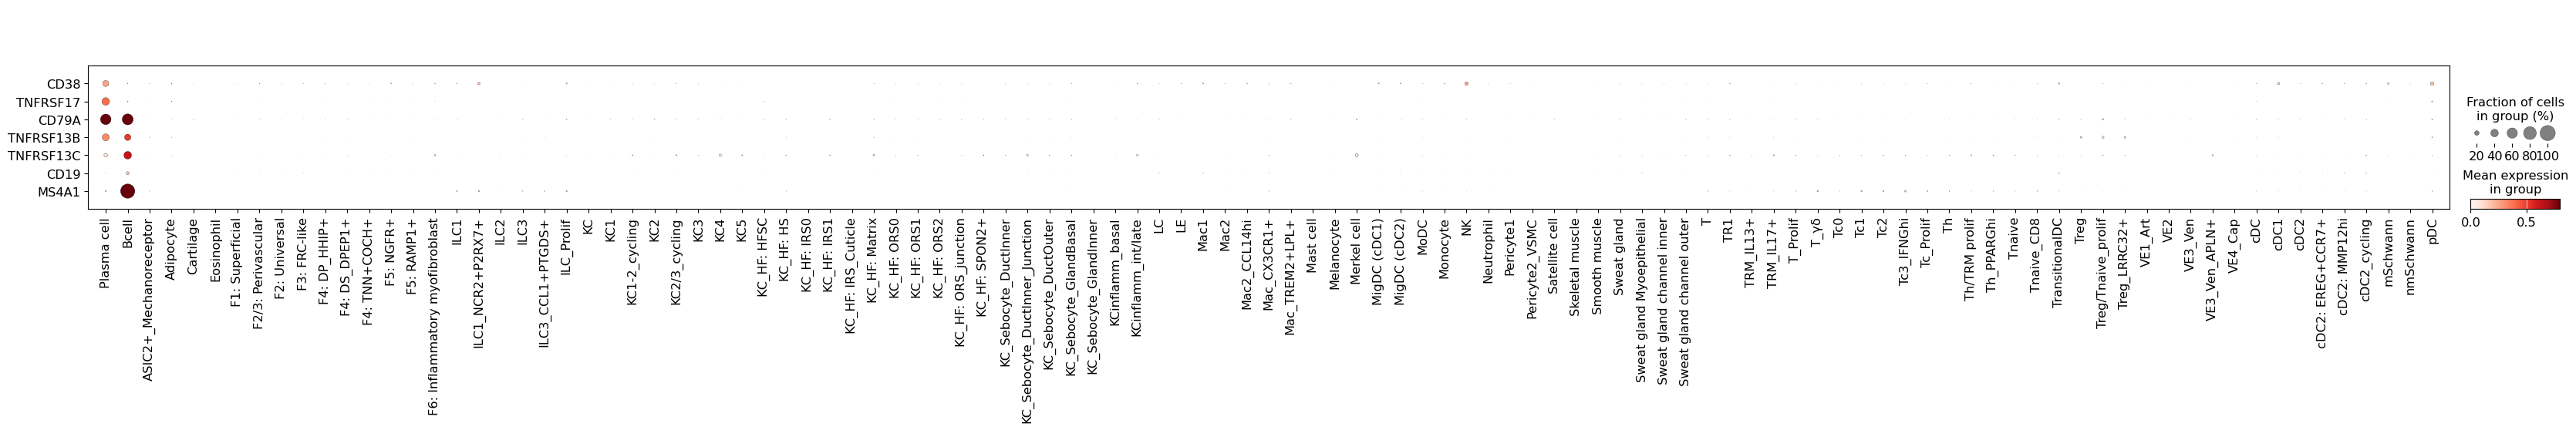

In [11]:
sc.pl.dotplot(
    adata,
     [ "CD38",    'TNFRSF17', "CD79A",
                'TNFRSF13B', 'TNFRSF13C', "CD19", "MS4A1", 
                    ],
    groupby="lvl5_annotation",
    vmax=0.8,
    swap_axes=True,
       # dot_max=0.3,
    save='plot_PLASMAMARKERSFORPROTEIN.pdf',
    categories_order=order
      #  title="TNFSF13(APRIL) + TNFRSF17 expression in scRNA"

    

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [12]:
sorted(adata.obs["lvl5_annotation"].unique())

['ASIC2+_Mechanoreceptor',
 'Adipocyte',
 'Bcell',
 'Cartilage',
 'Eosinophil',
 'F1: Superficial',
 'F2/3: Perivascular',
 'F2: Universal',
 'F3: FRC-like',
 'F4: DP_HHIP+',
 'F4: DS_DPEP1+',
 'F4: TNN+COCH+',
 'F5: NGFR+',
 'F5: RAMP1+',
 'F6: Inflammatory myofibroblast',
 'ILC1',
 'ILC1_NCR2+P2RX7+',
 'ILC2',
 'ILC3',
 'ILC3_CCL1+PTGDS+',
 'ILC_Prolif',
 'KC',
 'KC1',
 'KC1-2_cycling',
 'KC2',
 'KC2/3_cycling',
 'KC3',
 'KC4',
 'KC5',
 'KC_HF: HFSC',
 'KC_HF: HS',
 'KC_HF: IRS0',
 'KC_HF: IRS1',
 'KC_HF: IRS_Cuticle',
 'KC_HF: Matrix',
 'KC_HF: ORS0',
 'KC_HF: ORS1',
 'KC_HF: ORS2',
 'KC_HF: ORS_junction',
 'KC_HF: SPON2+',
 'KC_Sebocyte_DuctInner',
 'KC_Sebocyte_DuctInner_Junction',
 'KC_Sebocyte_DuctOuter',
 'KC_Sebocyte_GlandBasal',
 'KC_Sebocyte_GlandInner',
 'KCinflamm_basal',
 'KCinflamm_int/late',
 'LC',
 'LE',
 'Mac1',
 'Mac2',
 'Mac2_CCL14hi',
 'Mac_CX3CR1+',
 'Mac_TREM2+LPL+',
 'Mast cell',
 'Melanocyte',
 'Merkel cell',
 'MigDC (cDC1)',
 'MigDC (cDC2)',
 'MoDC',
 'Monocyt

In [13]:
# stop

In [14]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape



(2825, 32732)

In [15]:
sc.pp.normalize_total(adata_plasma, target_sum=1e4)
sc.pp.log1p(adata_plasma)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [16]:
adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
                              (adata_plasma.obs["Site_status"]=="Lesional")|
                              (adata_plasma.obs["Site_status"].str.startswith("3D"))|
                               (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
                               ]
adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

{x:x for x in adata_plasma_l.obs["t"].unique()}

RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
 'Bcell_ADLesional': 'Bcell_AD_Lesional',
 'Bcell_ADWeek 12': 'Bcell_AD_Week12',
 'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
 'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
 'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
 'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
 'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
 'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
 'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
 'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
 'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
 'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
adata_plasma_l.obs["t2"].value_counts()
# exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
#           ]
# adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

/tmp/ipykernel_456875/1676745639.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)


t2
Plasma cell_AD_Lesional           151
Bcell_Psoriasis_Lesional           83
Bcell_AD_Lesional                  75
Plasma cell_Psoriasis_Lesional     65
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


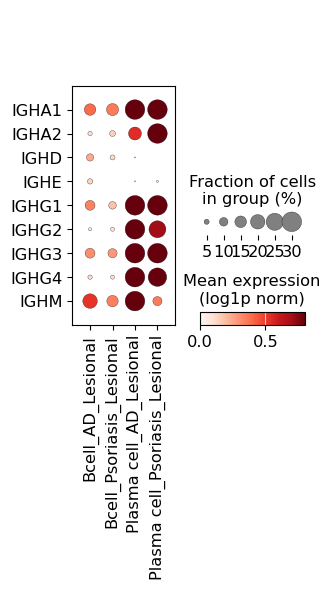

In [17]:
heavy_genes = ["IGHA1", "IGHA2", "IGHD","IGHE", "IGHG1", "IGHG2", "IGHG3", "IGHG4",  "IGHM", ]
sc.pl.dotplot(
    adata_plasma_l,
     heavy_genes,
    groupby="t2",
    vmax=0.8,
    swap_axes=True,
     dot_max=0.3,

    save='plotIGS_SCRNA.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


In [18]:

# adata_plasma.obs["t"] = adata_plasma.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma.obs["Patient_status"].astype(str)
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="t",
#     vmax=0.8,
#     swap_axes=True,
#      dot_max=0.3,

#     save='plotIGS.pdf',

# )


In [19]:
# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS.pdf',
#     title="Ig expression in scRNA plasma cells by patient status"

# )


In [20]:
# adata_plasma=adata[adata.obs["lvl5_annotation"]=="Bcell"]
# adata_plasma.shape

# heavy_genes = ["IGHM", "IGHD", "IGHG1", "IGHG2", "IGHG3", "IGHG4", "IGHA1", "IGHA2", "IGHE"]
# sc.pl.dotplot(
#     adata_plasma[adata_plasma.obs["Site_status_binary"]=="Lesional"],
#      heavy_genes,
#     groupby="Patient_status",
#     vmax=2,
#     swap_axes=True,
#        dot_max=0.3,

#     save='plotIGS_Bcell.pdf',
#     title="Ig expression in scRNA B-cells by patient status"

# )


In [21]:
cell_types = [
    "cDC1",
    "Mac2",
    "T",
    "Pericyte1",
    "Ve3_Ven",
    "Plasma cell",
    "Bcell",
    "F3: FRC-like",
    "VE1_Art",'VE3_Ven',
    "VE4_Cap",
   # 'mSchwann',
    #'nmSchwann',
    "F2/3: Perivascular"
]

ORDER = [


 'Plasma cell',
     "Bcell",
 'Sweat gland Myoepithelial',
         'Sweat gland',
          'Sweat gland channel outer',
 'Sweat gland channel inner',
 'VE1_Art','VE3_Ven',
 'VE4_Cap',
    'Mac2',
 'T',

 'cDC1',
'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
    # 'mSchwann',
   # 'nmSchwann',
]

adata=adata[(adata.obs["lvl5_annotation"].isin(cell_types))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
           ].copy()


In [22]:
import gc
gc.collect()

60809

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


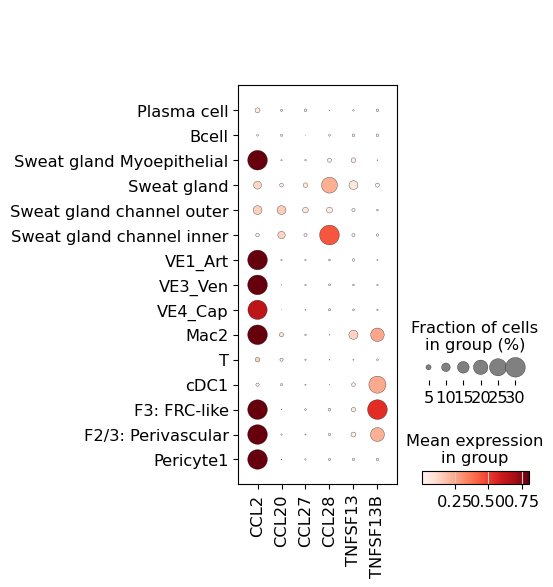

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


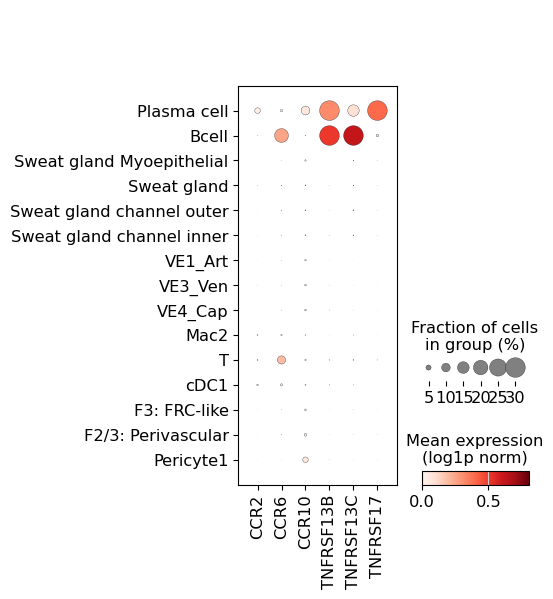

In [23]:
sc.pl.dotplot(
    adata,
     ["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B'],
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,

    save='4h_plasma_Cell_dotplot1.pdf'
)

sc.pl.dotplot(
    adata,
       ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    save='4h_plasma_Cell_dotplot2.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


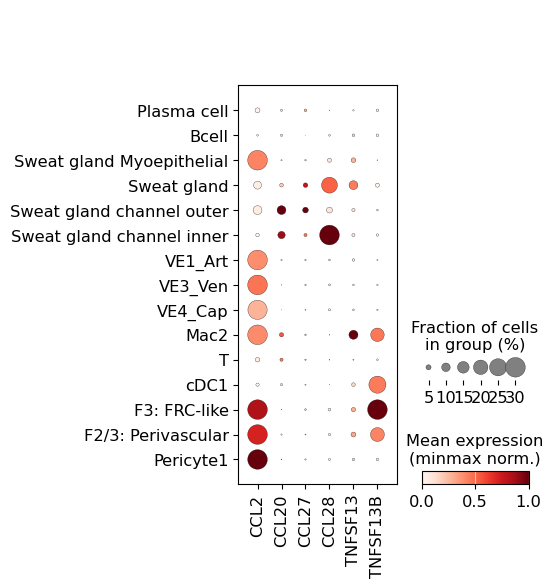

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


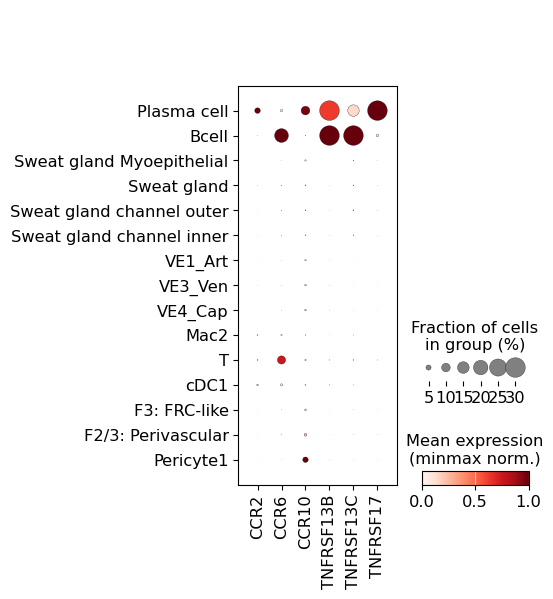

In [24]:
sc.pl.dotplot(
    adata,
     ["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B'],
    groupby="lvl5_annotation",
  #  vmax=0.8,
    categories_order=ORDER,
        dot_max=0.3,
    standard_scale="var",
    colorbar_title="Mean expression\n(minmax norm.)",

    save='4h_plasma_Cell_dotplot1.pdf'
)

sc.pl.dotplot(
    adata,
       ["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17'],
    groupby="lvl5_annotation",
    #vmax=0.8,
    dot_max=0.3,
        standard_scale="var",

    categories_order=ORDER,
    colorbar_title="Mean expression\n(minmax norm.)",
    save='4h_plasma_Cell_dotplot2_minmax.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


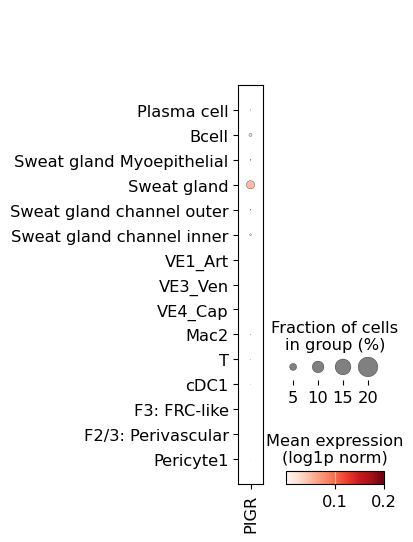

In [25]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.2,
    categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp_plasma_Cell_PIGRscrna.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


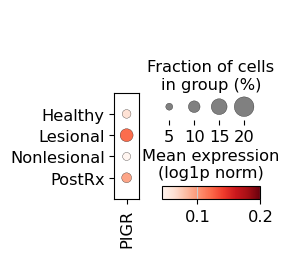

In [26]:
# sc.pl.dotplot(
#     adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
#      ["PIGR"],
#     groupby="sample_id",
#     vmax=0.2,
#     #categories_order=ORDER,
#         dot_max=0.2,
#     colorbar_title="Mean expression\n(log1p norm)",
#     #save='supp_plasma_Cell_PIGRscrna.pdf'
# )
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     ["PIGR"],
    groupby="Site_status",
    vmax=0.2,
   # categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp_plasma_Cell_PIGRscrna.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


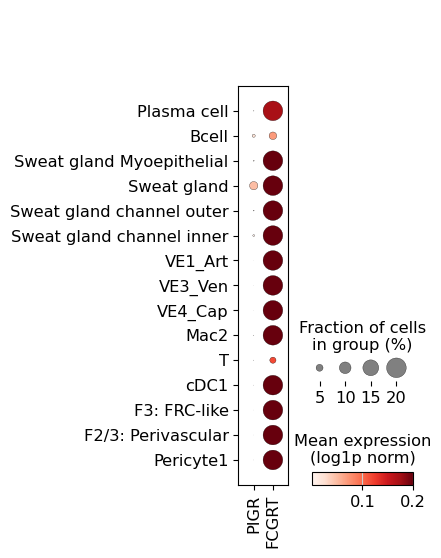

In [27]:
sc.pl.dotplot(
    adata,
     ["PIGR", "FCGRT"],
    groupby="lvl5_annotation",
    vmax=0.2,
    categories_order=ORDER,
        dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
   # save='supp_plasma_Cell_PIGRscrna.pdf'
)



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


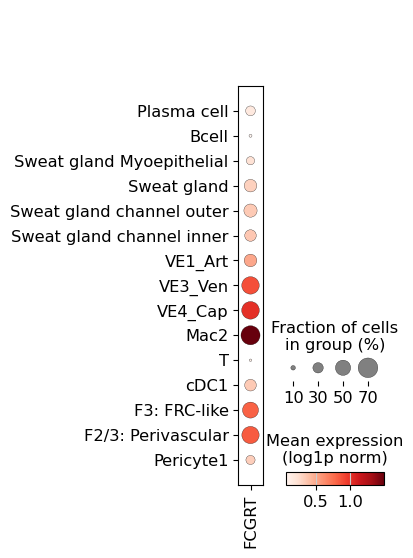

In [28]:
sc.pl.dotplot(
    adata,
     [ "FCGRT"],
    groupby="lvl5_annotation",
    #vmax=0.2,
    categories_order=ORDER,
       # dot_max=0.2,
    colorbar_title="Mean expression\n(log1p norm)",
   # save='supp_plasma_Cell_PIGRscrna.pdf'
)



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


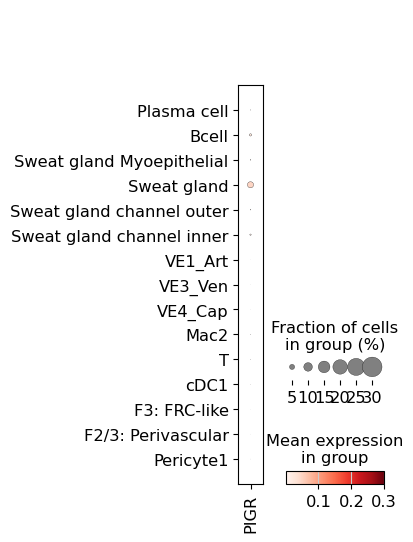

In [29]:
sc.pl.dotplot(
    adata,
     ["PIGR",],
    groupby="lvl5_annotation",
    vmax=0.3,
    categories_order=ORDER,
        dot_max=0.3,

    save='supp_plasma_Cell_PIGRscrna0.3.pdf'
)


# xenium validation (sFig 16b)

In [30]:
import scanpy as sc
adata=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.addrelapse')
import gc
gc.collect()
adata=adata[adata.obs["tech"]=="xenium"]
adata=adata[adata.obs["all_vs_core"]!="relapse"]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata.var_names]
    return LIST

 


In [31]:

# genes = adata.var.index.tolist()

# with open("/nfs/team298/ls34/xenium_genes.pkl", "wb") as f:
#     pickle.dump(genes, f)

In [32]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


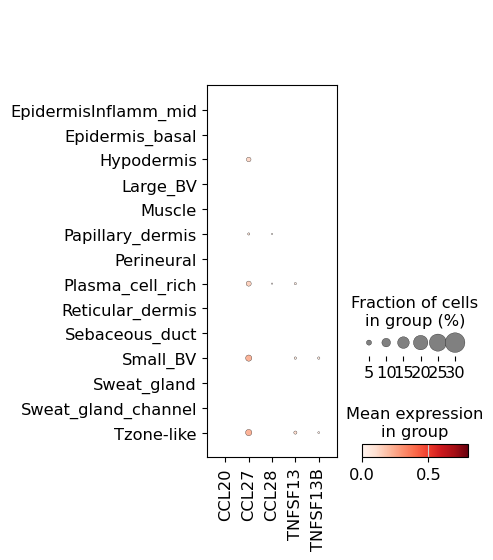

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


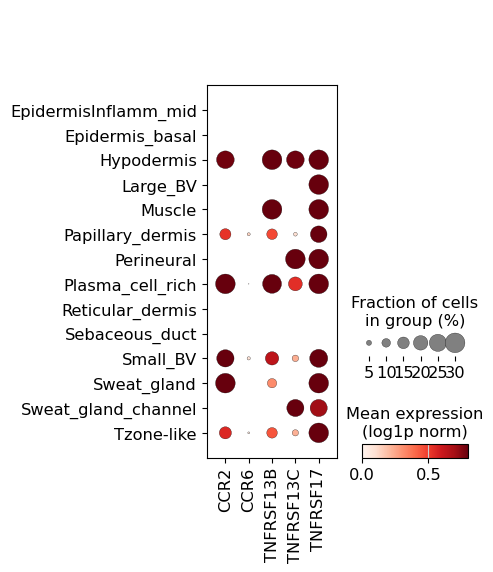

In [33]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
   # categories_order=ORDER,
        dot_max=0.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",  "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


In [34]:
# adata_i.obs["niche19"].value_counts()
 

NameError: name 'adata_i' is not defined

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


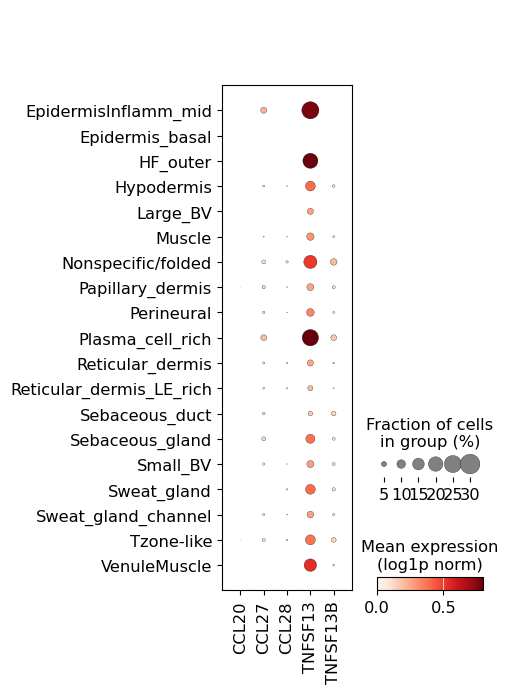

In [36]:
adata_i = adata[adata.obs["lvl5_annotation"]=="Mac2"]
# get counts
counts = adata_i.obs["niche19"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["niche19"].isin(keep)].copy()
sc.pl.dotplot(
    adata_i,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


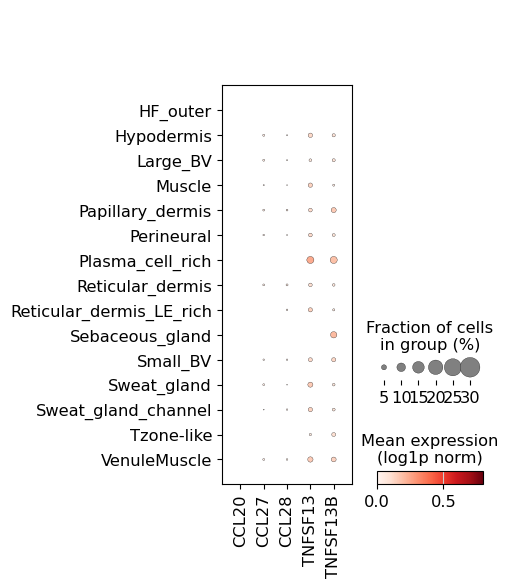

In [37]:
adata_i = adata[adata.obs["lvl5_annotation"]=="F2/3: Perivascular"]
# get counts
counts = adata_i.obs["niche19"].value_counts()

# keep categories with >=10 cells
keep = counts[counts >= 10].index

# filter AnnData
adata_i = adata_i[adata_i.obs["niche19"].isin(keep)].copy()
sc.pl.dotplot(
    adata_i,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="niche19",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)


In [38]:
adata[adata.obs["niche19"]=="Plasma_cell_rich"].obs.sample_id.value_counts().head(6).index

CategoricalIndex(['BK27_Week 12', 'BK27_Lesional Baseline',
                  'BK27_Non-lesional Baseline', 'BK20_Week 12', 'BK23_Week 12',
                  'BK24_Lesional Baseline'],
                 categories=['3D_BK25_week12-C2', '3D_BK25_week12-D1orE1a', '3D_BK25_week12-D1orE1b', '3D_BK25_week12-D2', ..., 'Week 8 (resolved)_CE3-SKI-28-FO-4-S22-E1_a', 'Week 8 (resolved)_CE3-SKI-28-FO-4-S22_replicate', 'Week 8 (resolved)_CE5-SKI-27-FO-4-S22-E1', 'Week 8 (resolved)_CE5-SKI-27-FO-4-S22_replicate'], ordered=False, dtype='category', name='sample_id')

In [39]:
KEEP =['BK27_Week 12', 'BK27_Lesional Baseline',
                  'BK27_Non-lesional Baseline', 'BK20_Week 12', 'BK23_Week 12',
                  'BK24_Lesional Baseline']
adata.obs["pc"] = ["PC+" if x in KEEP else "other" for x in adata.obs["sample_id"]]

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


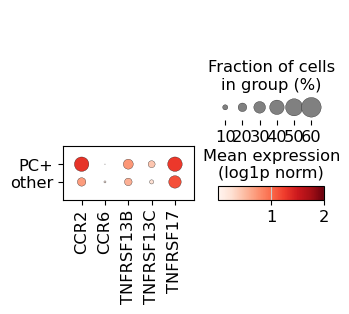

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


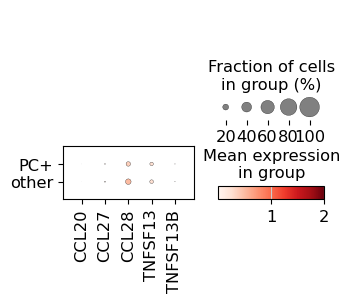

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


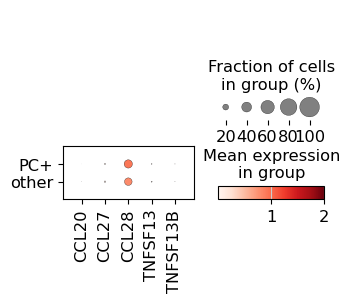

In [40]:
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Plasma cell"],
       remove_markers(["CCR2", "CCR6",   "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="pc",
    vmax=2,
    dot_max=0.6,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"]=="Sweat gland"],
     remove_markers(["CCL2", "CCL20", "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="pc",
    vmax=2,
   # categories_order=ORDER,
        dot_max=1,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)
sc.pl.dotplot(
    adata[adata.obs["lvl5_annotation"].str.startswith("Sweat gland channel")],
     remove_markers(["CCL2", "CCL20",   "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="pc",
    vmax=2,
   # categories_order=ORDER,
        dot_max=1,

    #save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

In [41]:
import pandas as pd

subset = adata.obs[adata.obs["niche19"].str.startswith("Plasma")]
vc = subset["lvl5_annotation"].value_counts()
vc


lvl5_annotation
Plasma cell           365
Pericyte1              27
VE3_Ven                19
F3: FRC-like           18
Mac2                   17
                     ... 
KC_HF: ORS1             0
KC_HF: ORS0             0
KC_HF: Matrix           0
KC_HF: IRS_Cuticle      0
pDC                     0
Name: count, Length: 100, dtype: int64

In [42]:
vc_filtered = vc[vc >= 10]



adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))|
              (adata.obs["lvl5_annotation"].str.startswith("Bc"))
           ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
              (adata.obs["lvl5_annotation"].str.startswith("Bc"))|
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Sweat gland                  23523
Sweat gland channel outer    19951
Sweat gland channel inner    10168
Sweat gland Myoepithelial     5653
Plasma cell                    365
Bcell                          219
Pericyte1                       27
VE3_Ven                         19
F3: FRC-like                    18
Mac2                            17
VE1_Art                         16
T                               14
F2/3: Perivascular              13
cDC1                            12
VE4_Cap                         10
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


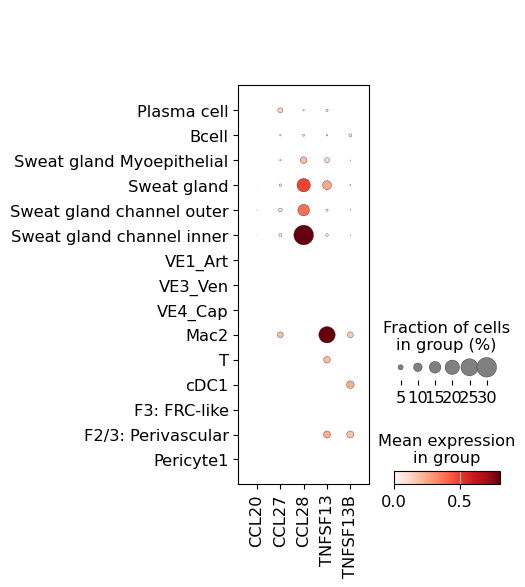

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


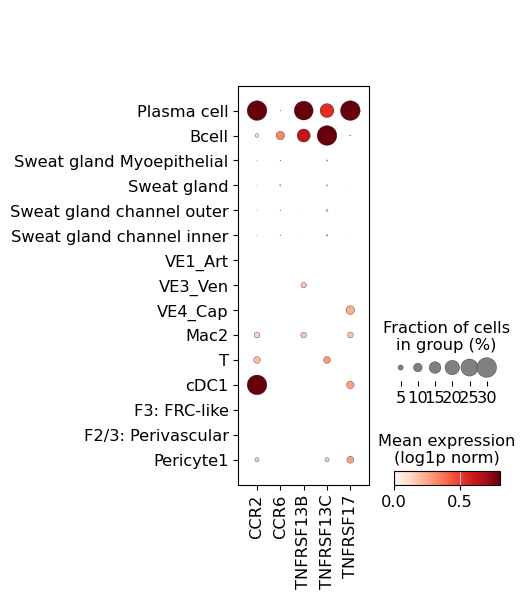

In [43]:

ORDER = [


 'Plasma cell',
     "Bcell",
 'Sweat gland Myoepithelial',
         'Sweat gland',
          'Sweat gland channel outer',
 'Sweat gland channel inner',
 'VE1_Art','VE3_Ven',
 'VE4_Cap',
    'Mac2',
 'T',

 'cDC1',
'F3: FRC-like', "F2/3: Perivascular", 'Pericyte1', 
    
    # 'mSchwann',
   # 'nmSchwann',
]
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20",  "CCL27", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
    categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
        dot_max=0.3,

    save='supp16_plasma_Cell_dotplot1_XENIUM.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    categories_order=[x for x in ORDER if x in adata.obs.lvl5_annotation.unique()],
    colorbar_title="Mean expression\n(log1p norm)",
    save='supp16_plasma_Cell_dotplot2_XENIUM.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [44]:

# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))|
#            (adata.obs["lvl5_annotation"].str.startswith("Sweat"))
#            ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))
           |
           (adata.obs["lvl5_annotation"].str.startswith("Sweat"))].copy()
adata.obs["lvl5_annotation"].value_counts()


lvl5_annotation
Sweat gland                  23523
Sweat gland channel outer    19951
Sweat gland channel inner    10168
Sweat gland Myoepithelial     5653
Plasma cell                    365
Pericyte1                       27
VE3_Ven                         19
F3: FRC-like                    18
Mac2                            17
VE1_Art                         16
T                               14
F2/3: Perivascular              13
cDC1                            12
VE4_Cap                         10
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


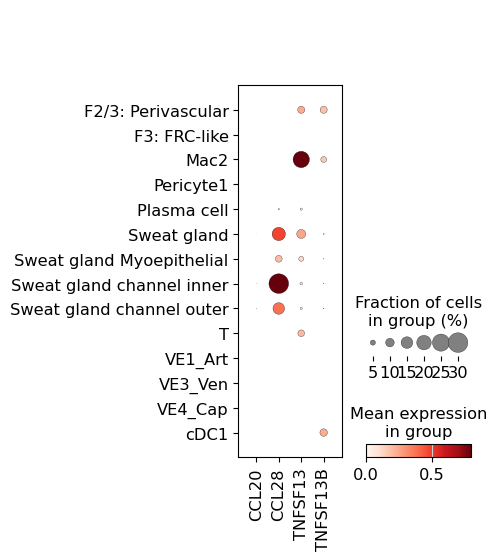

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


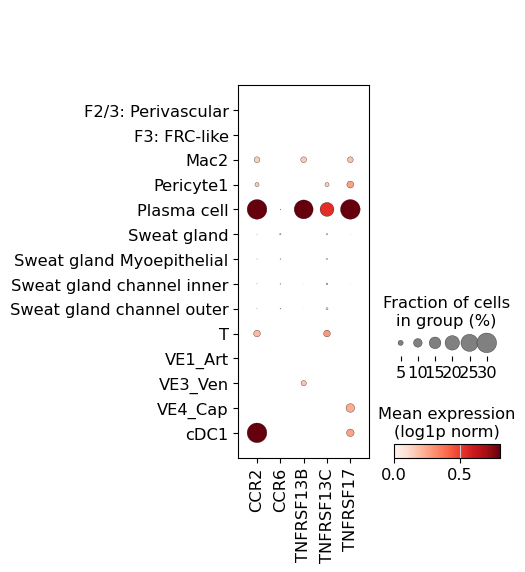

In [45]:
sc.pl.dotplot(
    adata,
     remove_markers(["CCL2", "CCL20", "CCL28", 'TNFSF13', 'TNFSF13B']),
    groupby="lvl5_annotation",
    vmax=0.8,
   # categories_order=ORDER,
        dot_max=0.3,

    #save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)

sc.pl.dotplot(
    adata,
       remove_markers(["CCR2", "CCR6", "CCR10", 'TNFRSF13B', 'TNFRSF13C', 'TNFRSF17']),
    groupby="lvl5_annotation",
    vmax=0.8,
    dot_max=0.3,
    #categories_order=ORDER,
    colorbar_title="Mean expression\n(log1p norm)",
    #save='supp16_plasma_Cell_dotplot2_XENIUM_allcells.pdf'
)

# dp = dp.style(
#     cmap='Reds',
#     color_on='square',
#     dot_edge_color='white',
#     dot_edge_lw=1,
#     grid=False,
#     dot_max=0.6,
#     categories_order=ORDER
# )

# dp.savefig("fig5/", dpi=300)

# #dp.show()
   

In [46]:
# sc.pl.dotplot(
#     adata,
#      remove_markers(["PIGR",]),
#     groupby="lvl5_annotation",
#     vmax=0.8,
#     categories_order=ORDER,
#         dot_max=0.6,

#     save='4k_plasma_Cell_PIGRxenium.pdf'
# )


In [47]:
# requested plot


In [48]:
# sc.settings.set_figure_params(dpi_save=600, facecolor="white", frameon=False, figsize=(17,17))

# NICHE =  'Plasma_cell_rich'
# MIN_NUMBER_CELLS=10

# CORE_PAPER =["BK23_Week 12",
#                                        "BK27_Week 12",
#                                       'BK27_Lesional Baseline',
#                                          'BK24_Lesional Baseline']
# for i, tissue_section_id in enumerate(CORE_PAPER):
#     print(tissue_section_id)
#    # print(i, "/", len(adata_5k.obs["info_id6"].unique()))
#     adata_i =  adata[adata.obs["info_id6"]==tissue_section_id]


#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.02,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds",
#         save=f"plotAPRILspatial_{i}.pdf"
#     )
#     #     if i>1:
#     #         break

 
 
       

In [49]:
# for x in [ 'BK39_Lesional Baseline',  'BK22_Lesional Baseline',
#           'Lesional_CE3-SKI-24-FO-1-S22-A1',
#         #  'Lesional_Baseline_resolved_CE3-SKI-24-FO-1-S22_replicate',
#           # 'Lesional_CE3-SKI-24-FO-1-S22_replicate',
#            'Lesional_CE4-SKI-27-FO-4-S22-A2',
#       #'Lesional_CE4-SKI-27-FO-4-S22_replicate',

#          ]:
#     adata_i=adata[adata.obs["info_id6"]==x]

   
#     sc.pl.spatial(
#         adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
#        # library_id="spatial",
#       #  shape=None,
#         color=["TNFSF13"],
#         spot_size=10,
#         vmax=1,
#                 edgecolor="black",
#         linewidth=0.05,
#                 legend_fontsize=12,
#       #  title=x,
#         legend_loc=None,
#            cmap="Reds"
#     )
#     #     if i>1:
#     #         break

 
 


In [50]:
# sc.pl.dotplot(
#     adata,
#      remove_markers([ 'TNFSF13', 
#                     'TNFRSF17'
#                     ]),
#     groupby="lvl5_annotation",
#     vmax=0.8,
#         dot_max=0.3,
#     save='plotTNFRSF17_TNFSF13_xenium.pdf',
#     swap_axes=True,
#     title="TNFSF13(APRIL) + TNFRSF17 expression in xenium"

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [51]:
adata_plasma=adata[(adata.obs["lvl5_annotation"]=="Plasma cell")|
                  (adata.obs["lvl5_annotation"]=="Bcell")
                  ]
adata_plasma.shape


(365, 4993)

In [52]:
adata_plasma.obs["niche19"].value_counts()

niche19
Plasma_cell_rich    365
Name: count, dtype: int64

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


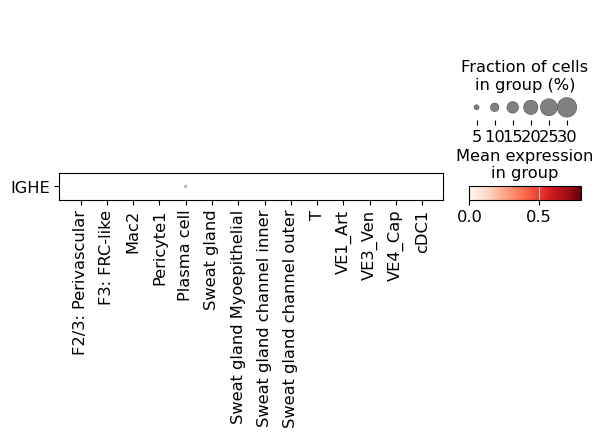

In [53]:
sc.pl.dotplot(
    adata,
     remove_markers([ #'TNFSF13', 
                    #'TNFRSF17', 
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [54]:
niche_counts = adata_plasma.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma = adata_plasma[adata_plasma.obs["niche19"].isin(valid)].copy()
adata_plasma.obs["niche19"] = adata_plasma.obs["niche19"].cat.remove_unused_categories()

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


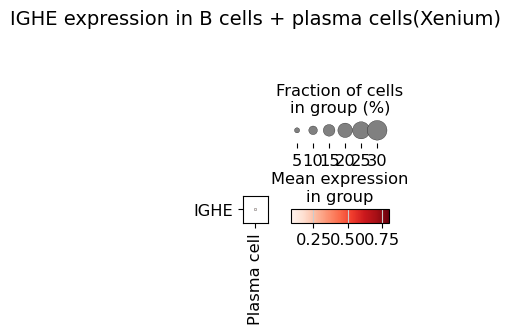

In [55]:
sc.pl.dotplot(
    adata_plasma,#[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="lvl5_annotation",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
    title="IGHE expression in B cells + plasma cells(Xenium)"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


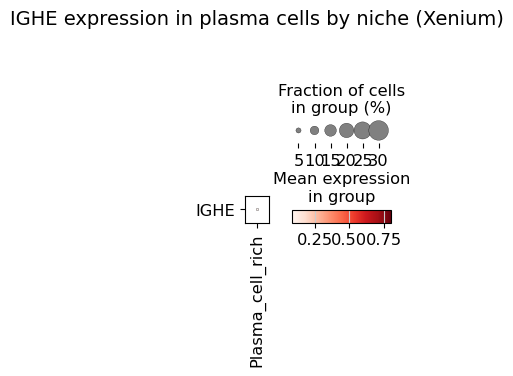

In [56]:
sc.pl.dotplot(
    adata_plasma[adata_plasma.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
        save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [57]:
# sc.pl.dotplot(
#     adata,
#      remove_markers([ 'TNFSF13', 
#                     'TNFRSF17', 
#                      "IGHE",
#                     ]),
#     groupby="",
#     vmax=0.8,
#         dot_max=0.3,
#     swap_axes=True

#   #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
# )


In [88]:
adata_relapse=sc.read_h5ad('/lustre/scratch124/cellgen/haniffa/projects/adult_skin_v1/nobackup_output/adata_relapse_xenium.h5ad')


In [89]:
adata_plasma=adata_relapse[(adata_relapse.obs["scanvi_predictions"]=="Plasma cell")|
                  (adata_relapse.obs["scanvi_predictions"]=="Bcell")
                  ]
adata_plasma.shape


(116, 5094)

In [90]:
adata_plasma.obs["scanvi_predictions"].value_counts()

scanvi_predictions
Plasma cell    95
Bcell          21
Name: count, dtype: int64

In [91]:
adata_plasma.obs["Site_status"].value_counts()

Series([], Name: count, dtype: int64)

In [92]:
# adata_plasma_l = adata_plasma[(adata_plasma.obs["Site_status"]=="Week 12")|
#                               (adata_plasma.obs["Site_status"]=="Lesional")|
#                               (adata_plasma.obs["Site_status"].str.startswith("3D"))|
#                                (adata_plasma.obs["Site_status"]=="Psoriasis_replicate_Lesional")
                              
#                                ]


In [93]:
# adata_plasma_l.obs["t"] = adata_plasma_l.obs["lvl5_annotation"].astype(str)+"_" + adata_plasma_l.obs["Patient_status"].astype(str) + adata_plasma_l.obs["Site_status"].astype(str)

# {x:x for x in adata_plasma_l.obs["t"].unique()}



In [94]:
# adata_plasma_l[adata_plasma_l.obs["t"]== 'Plasma cell_3d_Week123D_Week12'].obs.info_id6.value_counts()

In [95]:
# RENAME = {'Plasma cell_ADLesional': 'Plasma cell_AD_Lesional',
#  'Bcell_ADLesional': 'Bcell_AD_Lesional',
#  'Bcell_ADWeek 12': 'Bcell_AD_Week12',
#  'Plasma cell_ADWeek 12': 'Plasma cell_AD_Week12',
#  'Plasma cell_PsoriasisLesional': 'Plasma cell_Psoriasis_Lesional',
#  'Bcell_PsoriasisLesional': 'Bcell_Psoriasis_Lesional',
#  'Bcell_nanPsoriasis_replicate_Lesional': 'Bcell_Psoriasis_Lesional',
#  'Plasma cell_nanPsoriasis_replicate_Lesional': 'Plasma cell_Psoriasis_Lesional',
#  'Bcell_3d_Lesional_baseline3D_Lesional_baseline': 'Bcell_AD_Lesional',
#  'Plasma cell_3d_Lesional_baseline3D_Lesional_baseline': 'Plasma cell_AD_Lesional',
#  'Bcell_3d_Week123D_Week12': 'Bcell_AD_Week12',
#  'Plasma cell_3d_Week123D_Week12': 'Plasma cell_AD_Week12',
#  'Plasma cell_3d_Lesional_baseline3D_Week12': 'Plasma cell_AD_Week12',
#  'Bcell_3d_Lesional_baseline3D_Week12': 'Bcell_AD_Week12'}
# adata_plasma_l.obs["t2"]=adata_plasma_l.obs["t"].map(RENAME)
# adata_plasma_l.obs["t2"].value_counts()
# # exclude = ['Bcell_nanPsoriasis_replicate_Lesional',
           
# #           ]
# # adata_plasma_l=adata_plasma_l[~adata_plasma_l.obs["t"].isin(exclude)]

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


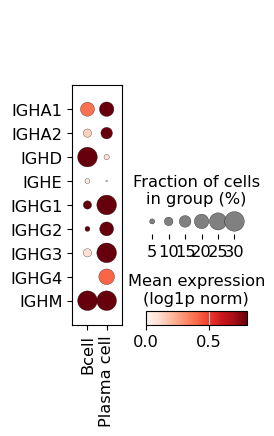

In [102]:
heavy_genes = [ "IGHA1", "IGHA2", 
                "IGHD", 
               "IGHE",
              "IGHG1", "IGHG2", "IGHG3", "IGHG4",
              
              "IGHM",]
sc.pl.dotplot(
    adata_plasma,
    heavy_genes,
    groupby="scanvi_predictions",
    vmax=0.8,
   swap_axes=True,
     dot_max=0.3,

    save='plotIGS_xenium_relapse.pdf',
    colorbar_title='Mean expression\n(log1p norm)'

)


In [ ]:
adata_plasma_l.obs.niche19.value_counts()

In [ ]:
niche_counts = adata_plasma_l.obs["niche19"].value_counts()
valid = niche_counts[niche_counts >= 10].index
adata_plasma_l = adata_plasma_l[adata_plasma_l.obs["niche19"].isin(valid)].copy()
adata_plasma_l.obs["niche19"] = adata_plasma_l.obs["niche19"].cat.remove_unused_categories()

In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Plasma cell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
       # save="IGs_inplasmacell_byniche.pdf",
    title="IGHE expression in plasma cells by niche (Xenium)",
    save="IGs_by_niche.pdf"

  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
sc.pl.dotplot(
    adata_plasma_l[adata_plasma_l.obs["lvl5_annotation"]=="Bcell"],
     remove_markers([  
                     "IGHE",
                    ]),
    groupby="niche19",
    vmax=0.8,
        dot_max=0.3,
    swap_axes=True,
     save="IGs_inBcell_byniche.pdf",
    title="IGHE expression in B cells by niche (Xenium)"


  #  save='supp16_plasma_Cell_dotplot1_XENIUM_allcells.pdf'
)


In [ ]:
vc_filtered = vc[vc >= 10]

adata=adata[(adata.obs["niche19"].str.startswith("Plasma"))
           ]
adata=adata[(adata.obs["lvl5_annotation"].isin(vc_filtered.index.to_list()))]
adata.obs["lvl5_annotation"].value_counts()

import pandas as pd
CATEGORY="lvl5_annotation"
sc.tl.rank_genes_groups(adata, CATEGORY, method='wilcoxon', key_added="de_leiden");
df2 = pd.DataFrame(adata.uns['de_leiden']['names'])
for i,x in enumerate(df2.columns):
    print(i, " : ", x) 

In [ ]:
df2.head(50)


### 